In [258]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
import matplotlib.pyplot as plt
import numpy as np

## Универсальная функция чтения

In [259]:
def load_scalar(run_path, tag):
    event_file = next(
        os.path.join(run_path, f)
        for f in os.listdir(run_path)
        if f.startswith("events.out")
    )

    ea = EventAccumulator(event_file)
    ea.Reload()

    events = ea.Scalars(tag)

    steps = [e.step for e in events]
    values = [e.value for e in events]

    return steps, values

## Чтение данных

In [260]:
runs = [
    "logs/run_1",
    "logs/run_2",
    "logs/run_3",
    "logs/run_4",
    "logs/run_5",
]

In [261]:
SKIP_FIRST = 1000      # подобрать экспериментально
DROP_LAST = 100
THRESHOLD = 850

reward_steps = []
reward_values = []

length_steps = []
length_values = []

for i, run in enumerate(runs):

    s, v = load_scalar(run, "Train/mean_reward")

    if i == 0:
        s = s[:-DROP_LAST * 4]
        v = v[:-DROP_LAST * 4]
    else:           # первый запуск не трогаем
        s = s[SKIP_FIRST:-DROP_LAST * 4]
        v = v[SKIP_FIRST:-DROP_LAST * 4]

    reward_steps.extend(s)
    reward_values.extend(v)

    s, v = load_scalar(run, "Train/mean_episode_length")

    if i == 0:
        s = s[:-DROP_LAST]
        v = v[:-DROP_LAST]

        s = np.array(s)
        v = np.array(v)

        mask = v >= THRESHOLD

        s = s[mask]
        v = v[mask]
    elif i == 4:
        s = s[SKIP_FIRST:-DROP_LAST]
        v = v[SKIP_FIRST:-DROP_LAST]
    else:
        s = s[SKIP_FIRST:]
        v = v[SKIP_FIRST:]

    length_steps.extend(s)
    length_values.extend(v)

## Объединение данных

### mean_reward

In [262]:
reward_dict = {}

for step, value in zip(reward_steps, reward_values):
    reward_dict[step] = value      # если шаг повторяется, останется последнее значение

reward_steps = sorted(reward_dict.keys())
reward_values = [reward_dict[s] for s in reward_steps]

print(f"Количество точек после объединения: {len(reward_steps)}")
print(f"Первый шаг: {reward_steps[0]}")
print(f"Последний шаг: {reward_steps[-1]}")

Количество точек после объединения: 23596
Первый шаг: 0
Последний шаг: 29599


### mean_episode_length

In [263]:
length_dict = {}

for step, value in zip(length_steps, length_values):
    length_dict[step] = value

length_steps = sorted(length_dict.keys())
length_values = [length_dict[s] for s in length_steps]

print(f"Количество точек после объединения: {len(length_steps)}")
print(f"Первый шаг: {length_steps[0]}")
print(f"Последний шаг: {length_steps[-1]}")

Количество точек после объединения: 25368
Первый шаг: 28
Последний шаг: 29899


## Построим графики

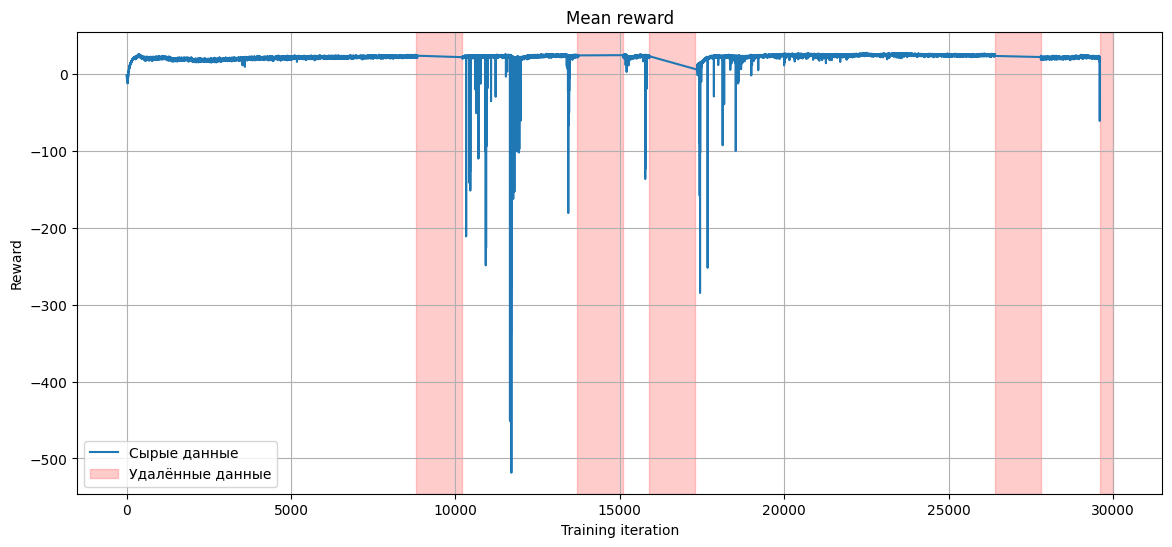

In [264]:
reward_zones = [
    (8800, 10200),
    (13700, 15100),
    (15900, 17300),
    (26400, 27800),
    (29600, 29999),
]

plt.figure(figsize=(14,6))

plt.plot(reward_steps, reward_values, label="Сырые данные")

for i, (x1, x2) in enumerate(reward_zones):
    plt.axvspan(
        x1, x2,
        color="red",
        alpha=0.2,
        label="Удалённые данные" if i == 0 else None
    )

plt.title("Mean reward")
plt.xlabel("Training iteration")
plt.ylabel("Reward")

plt.grid(True)
plt.legend()

plt.show()

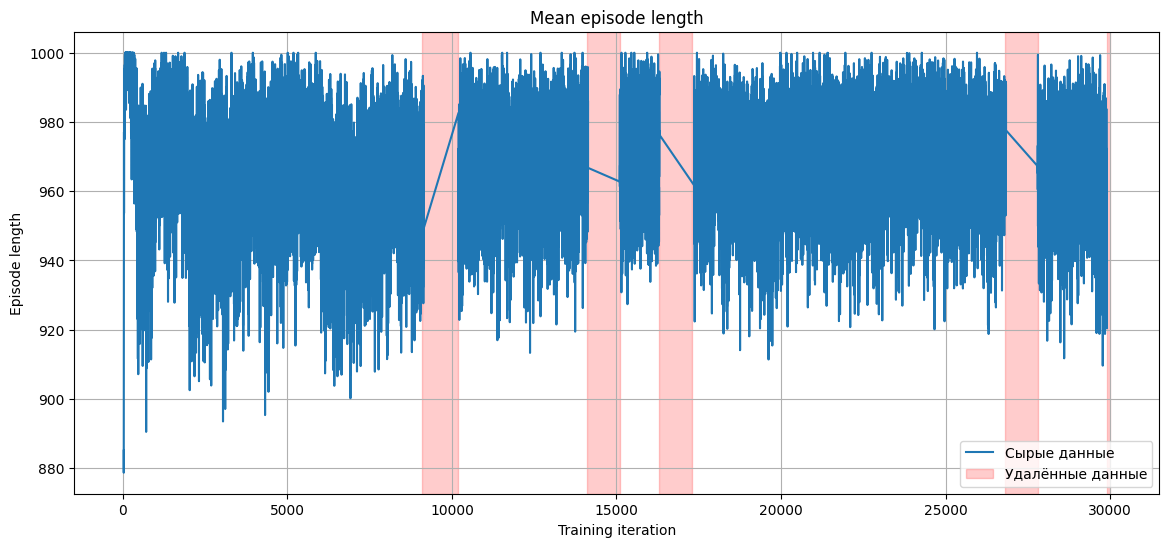

In [265]:
episode_zones = [
    (9100, 10200),
    (14100, 15100),
    (16300, 17300),
    (26800, 27800),
    (29900, 29999),
]

plt.figure(figsize=(14,6))

plt.plot(length_steps, length_values, label="Сырые данные")

for i, (x1, x2) in enumerate(episode_zones):
    plt.axvspan(
        x1, x2,
        color="red",
        alpha=0.2,
        label="Удалённые данные" if i == 0 else None
    )

plt.title("Mean episode length")
plt.xlabel("Training iteration")
plt.ylabel("Episode length")

plt.grid(True)
plt.legend()

plt.show()

## Построим финальные графики

### Функция сглаживания

In [266]:
def tensorboard_smooth(values, smoothing=0.6):
    """
    Экспоненциальное сглаживание как в TensorBoard.

    smoothing:
        0.0 — без сглаживания
        0.6 — умеренное
        0.9 — сильное
        0.98 — почти идеально гладкая линия
    """

    values = np.asarray(values)

    smoothed = np.zeros_like(values)

    smoothed[0] = values[0]

    for i in range(1, len(values)):
        smoothed[i] = (
            smoothing * smoothed[i-1]
            + (1 - smoothing) * values[i]
        )

    return smoothed

### Фильтр выбросов

In [267]:
def clip_spikes(x, y, max_jump=50):
    x = np.array(x)
    y = np.array(y)

    clean_y = y.copy()

    for i in range(1, len(y)):
        if abs(y[i] - y[i-1]) > max_jump:
            clean_y[i] = clean_y[i-1]

    return x, clean_y

### Ручное удаление выбросов

In [268]:
def fix_single_outlier(y, idx, window=5):
    y = y.copy()

    left = max(0, idx - window)
    right = min(len(y), idx + window)

    y[idx] = np.median(np.concatenate([y[left:idx], y[idx+1:right]]))

    return y

In [269]:
reward_bounds = []
step_offset = 0

for i, run in enumerate(runs):

    s, _ = load_scalar(run, "Train/mean_reward")

    start = 0 if i == 0 else SKIP_FIRST
    end = -DROP_LAST * 4

    s = s[start:end]

    if len(s) == 0:
        continue

    # --- границы удаления ---
    reward_bounds.append({
        "start": step_offset,
        "skip_end": step_offset + max(0, start),
        "end": step_offset + len(s)
    })

    step_offset += len(s)

### Mean Reward

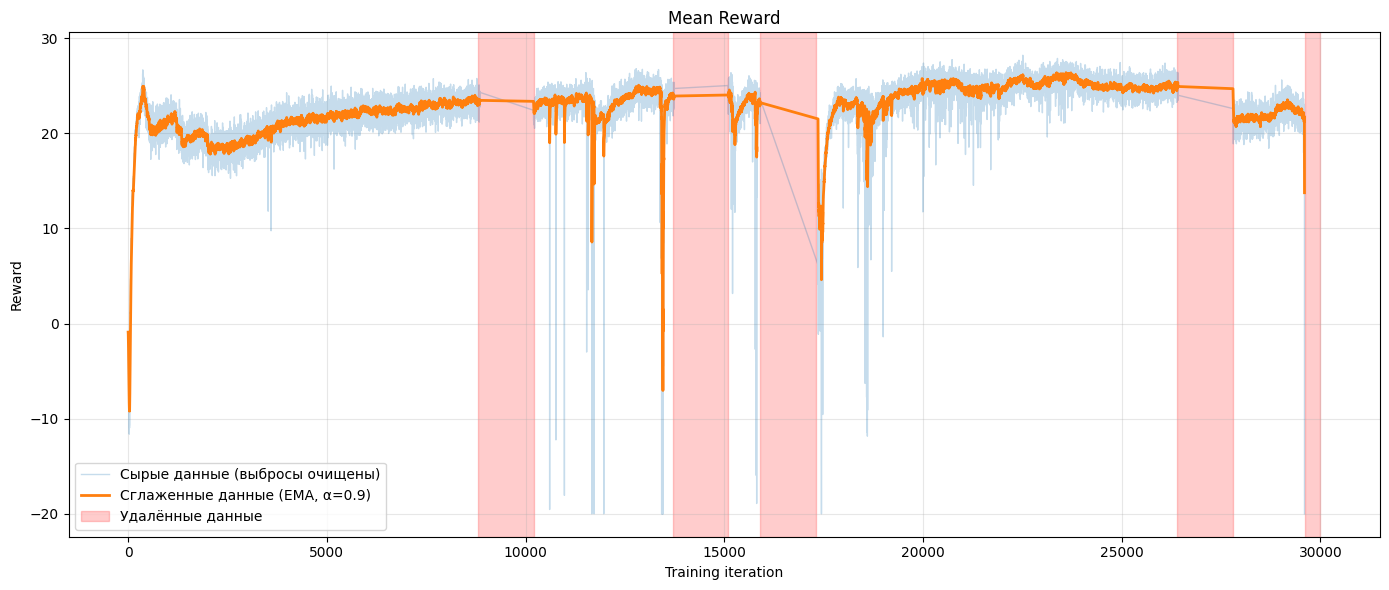

In [270]:
smooth = 0.90
reward_zones = [
    (8800, 10200),
    (13700, 15100),
    (15900, 17300),
    (26400, 27800),
    (29600, 29999),
]

# убираем выбросы
reward_steps_c, reward_values_c = clip_spikes(
    reward_steps, reward_values, max_jump=50
)

reward_values_c = np.array(reward_values_c)
reward_values_c = np.clip(reward_values_c, -20, None)

# сглаживание
reward_smooth = tensorboard_smooth(reward_values_c, smooth)

plt.figure(figsize=(14,6))

# Сырые данные с очисткой выбросов
plt.plot(
    reward_steps_c,
    reward_values_c,
    alpha=0.25,
    linewidth=1,
    label="Сырые данные (выбросы очищены)"
)

# Сглаженные данные
plt.plot(
    reward_steps_c,
    reward_smooth,
    linewidth=2,
    label=f"Сглаженные данные (EMA, α={smooth})"
)

# Зоны удаления данных
for i, (x1, x2) in enumerate(reward_zones):
    plt.axvspan(
        x1, x2,
        color="red",
        alpha=0.2,
        label="Удалённые данные" if i == 0 else None
    )

plt.title("Mean Reward")
plt.xlabel("Training iteration")
plt.ylabel("Reward")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Mean Episode Length

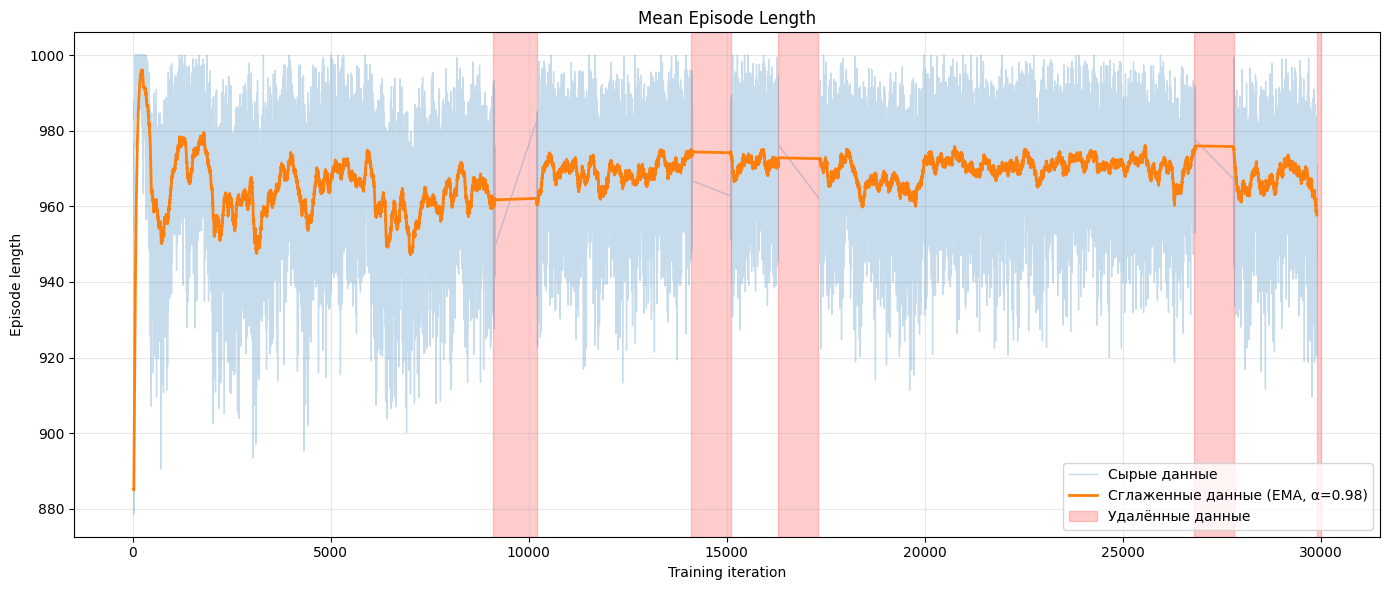

In [271]:
smooth = 0.98
length_smooth = tensorboard_smooth(length_values, smooth)
episode_zones = [
    (9100, 10200),
    (14100, 15100),
    (16300, 17300),
    (26800, 27800),
    (29900, 29999),
]

plt.figure(figsize=(14,6))

# Сырые данные
plt.plot(
    length_steps,
    length_values,
    alpha=0.25,
    linewidth=1,
    label="Сырые данные"
)

# Сглаженные данные
plt.plot(
    length_steps,
    length_smooth,
    linewidth=2,
    label=f"Сглаженные данные (EMA, α={smooth})"
)

# Зоны удаления данных
for i, (x1, x2) in enumerate(episode_zones):
    plt.axvspan(
        x1, x2,
        color="red",
        alpha=0.2,
        label="Удалённые данные" if i == 0 else None
    )

plt.title("Mean Episode Length")
plt.xlabel("Training iteration")
plt.ylabel("Episode length")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()